<a href="https://colab.research.google.com/github/NgocAnhNguyen-0601/-Crypto-Currency-Bitcoin-Price-Prediction-/blob/main/crypto_currency_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [2]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start = start, end = end)


/tmp/ipykernel_1908/1837361621.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start = start, end = end)
[*********************100%***********************]  1 of 1 completed


In [3]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [4]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-05-25,77279.929688,77804.921875,76833.039062,76981.125000,19808387601
2026-05-26,75825.734375,77990.867188,75569.468750,77280.125000,35999475458
2026-05-27,74344.703125,76014.296875,74136.500000,75825.304688,33802172927
2026-05-28,73536.554688,74460.125000,72493.414062,74339.570312,40148145327
2026-05-30,73433.320312,73694.625000,73331.015625,73369.125000,33808234496


In [5]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4273.000000,4273.000000,4273.000000,4273.000000,4.273000e+03
mean,28572.426254,29121.473380,27956.424122,28556.316306,2.226543e+10
std,32429.819874,32971.153217,31839.717483,32426.000542,2.293007e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,3448.116943,3495.174805,3372.120117,3421.910400,1.663280e+09
50%,11512.599609,11800.064453,11248.294922,11502.828125,1.800070e+10
75%,46306.445312,47313.828125,44705.554688,46280.847656,3.439874e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4273 entries, 2014-09-17 to 2026-05-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4273 non-null   float64
 1   (High, BTC-USD)    4273 non-null   float64
 2   (Low, BTC-USD)     4273 non-null   float64
 3   (Open, BTC-USD)    4273 non-null   float64
 4   (Volume, BTC-USD)  4273 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 200.3 KB


In [7]:
# Close Data Price
stock_data.columns
closing_price = stock_data[['Close']]
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2026-05-25,77279.929688
2026-05-26,75825.734375
2026-05-27,74344.703125


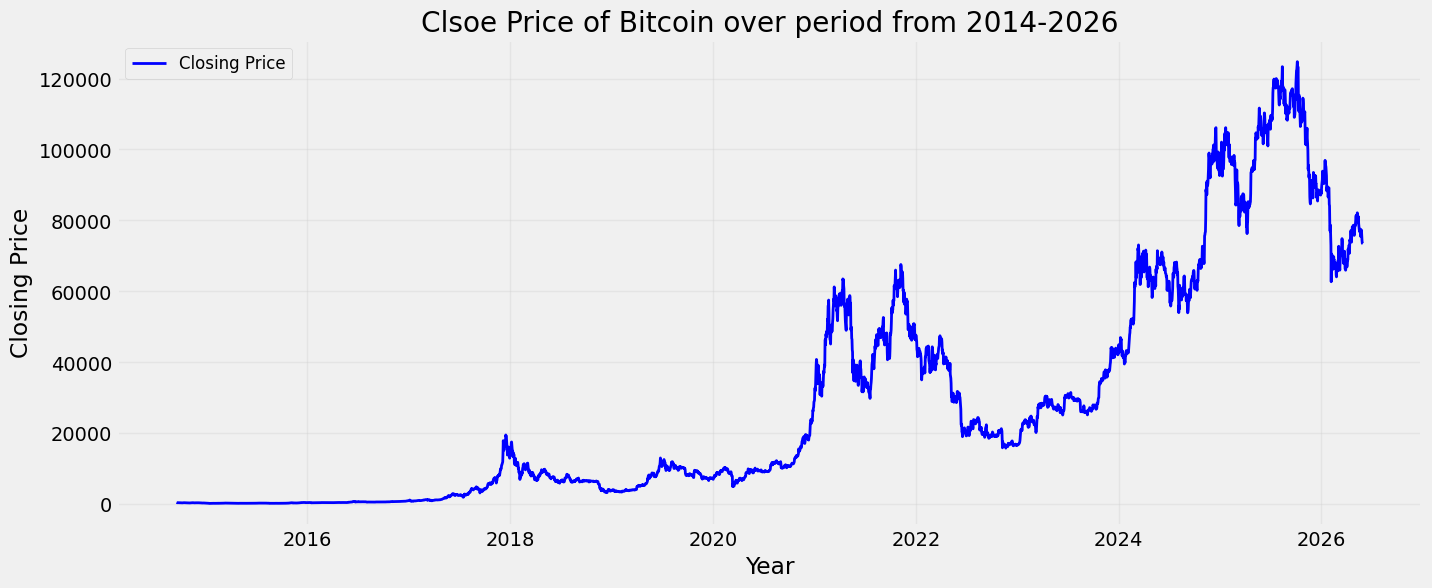

In [8]:
# Plot the closing price with trend:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.title("Clsoe Price of Bitcoin over period from 2014-2026")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [9]:
# Moving Average:
temp_data = [10,20,30,40,50,60,70,80,90,100]
# Moving avergae for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[0:5])/5)

30.0


In [11]:
df1 = pd.DataFrame(temp_data)

In [12]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [13]:
for i in range (2014, 2026):
  print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366
2025 365


In [16]:
closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/tmp/ipykernel_1908/3538707382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price["Close"].rolling(window = 365).mean()
/tmp/ipykernel_1908/3538707382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


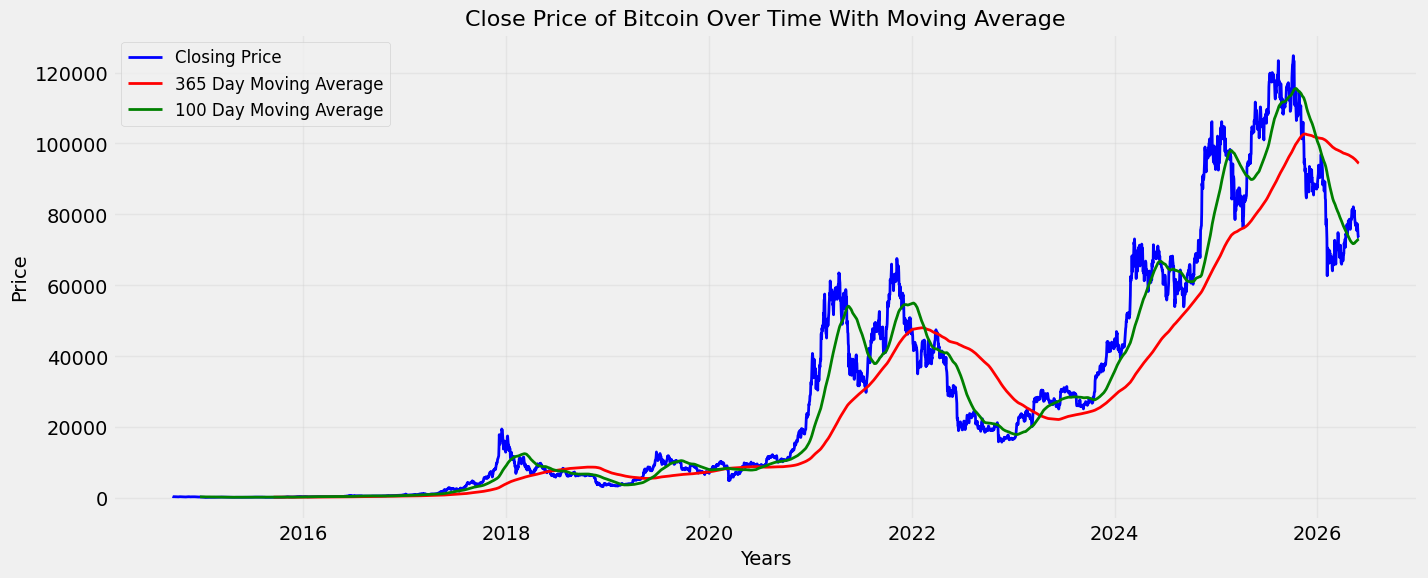

In [17]:
# PLot closing price with enhancement:
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Closing Price', color = 'Blue', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Day Moving Average', color = 'Red', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Day Moving Average', color = 'Green', linewidth = 2)

plt.title("Close Price of Bitcoin Over Time With Moving Average", fontsize = 16 )
plt.xlabel("Years", fontsize = 14)
plt.ylabel("Price", fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()


LSTM - Long Short Term Memory

In [18]:
# Scale the data:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [19]:
scaled_data

array([[0.00224148],
       [0.00197743],
       [0.00173947],
       ...,
       [0.59535975],
       [0.58887247],
       [0.58804378]])